# Task 2.1 Dataset Selection and Setup

Dataset follows the same pipeline used in `reproduction.ipynb` (Hedau loading with the same fallback logic).

- Dataset: Hedau indoor layout (same as reproduction)
- Why appropriate: same problem type as paper (room layout with clutter)
- Limitation vs original paper: simplified implementation and limited samples in training for CPU feasibility
- Preprocessing: same superpixel + feature extraction pipeline as in reproduction

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import requests
from scipy.io import loadmat
from skimage.segmentation import slic, find_boundaries
from skimage.feature import hog
from skimage.util import img_as_float
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import random
from tqdm import tqdm

# Random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Constants
DATA_DIR = Path('data')
HEDAU_URL = 'https://vision.cs.uiuc.edu/~vhedau2/Research/data/groundtruth.zip'
NYU_LABELED_URL = 'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat'

# Label mapping
FLOOR, WALL, CEILING = 0, 1, 2
HEDAU_TO_SEMANTIC = {1: FLOOR, 2: WALL, 3: WALL, 4: WALL, 5: CEILING, 6: WALL}

# Visualization Colors
GC_COLORS = np.array([[0, 128, 0], [255, 0, 0], [0, 0, 255]], dtype=np.uint8)  # Floor, Wall, Ceiling
OM_COLORS = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255]], dtype=np.uint8)  # Horizontal, V1, V2

print("Environment setup complete.")


Environment setup complete.


The next block is reused from `reproduction.ipynb` to keep the exact same data/database flow.

In [2]:
def download_hedau_groundtruth(data_dir=DATA_DIR):
    data_dir = Path(data_dir)
    hedau_dir = data_dir / 'hedau'
    hedau_dir.mkdir(parents=True, exist_ok=True)
    zip_path = hedau_dir / 'groundtruth.zip'
    if zip_path.exists():
        return str(hedau_dir)
    print('Downloading Hedau ground truth...')
    r = requests.get(HEDAU_URL, stream=True)
    r.raise_for_status()
    with open(zip_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(hedau_dir)
    return str(hedau_dir)

def load_groundtruth_with_images(hedau_dir, n_train=209, n_test=105):
    hedau_dir = Path(hedau_dir)
    gt_dir = hedau_dir / 'groundtruth'
    img_dir = gt_dir / 'Images' if (gt_dir / 'Images').exists() else hedau_dir / 'Images'
    mat_files = sorted(gt_dir.glob('*.mat')) if gt_dir.exists() else sorted(hedau_dir.rglob('*.mat'))
    if not mat_files:
        mat_files = sorted(hedau_dir.glob('*.mat'))
    pairs = []
    for m in mat_files:
        base_id = m.stem.replace('_labels', '')
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = img_dir / (base_id + ext)
            if img_path.exists():
                try:
                    rgb = cv2.imread(str(img_path))
                    if rgb is None: continue
                    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
                    d = loadmat(m)
                    lab = d.get('labels', d.get('fields', None))
                    if lab is None: continue
                    lab = np.squeeze(lab).astype(np.int32)
                    gt = np.zeros_like(lab, dtype=np.int32)
                    for src, tgt in HEDAU_TO_SEMANTIC.items():
                        gt[lab == src] = tgt
                    if rgb.shape[:2] != gt.shape:
                        gt = cv2.resize(gt.astype(np.float32), (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST).astype(np.int32)
                    pairs.append((rgb, gt))
                except Exception: pass
                break
    if not pairs: return [], []
    n = len(pairs)
    n_train = min(n_train, int(0.7 * n))
    n_test = min(n_test, n - n_train)
    return pairs[:n_train], pairs[n_train:n_train + n_test] if n_test > 0 else pairs[n_train:]

# Load Data
try:
    hedau_path = download_hedau_groundtruth()
    train_data, test_data = load_groundtruth_with_images(hedau_path)
    print(f'Loaded Hedau: {len(train_data)} train, {len(test_data)} test')
except Exception as e:
    print(f"Failed to load Hedau: {e}. Please ensure data is available.")
    train_data, test_data = [], []


Loaded Hedau: 209 train, 105 test


Dataset stats/sample visualization from the same reproduction notebook.

Dataset: Hedau Indoor Layout
  Training samples: 209
  Test samples: 105
  Sample image shape: (500, 666, 3)


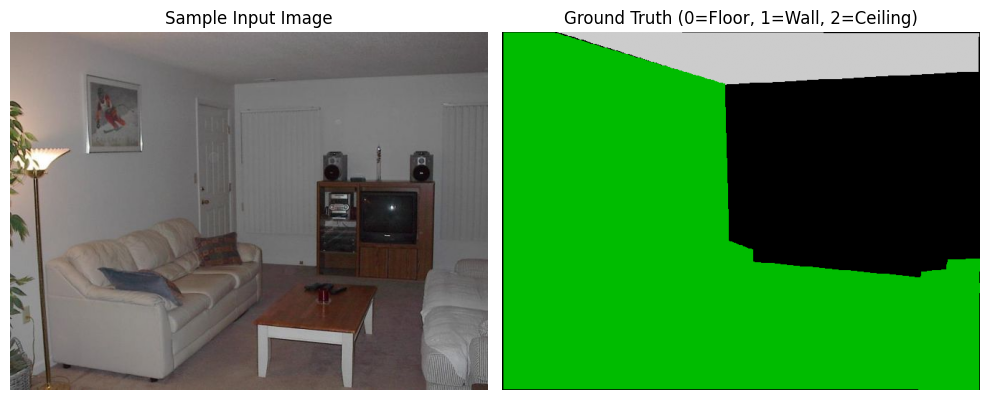

In [3]:
# Display dataset statistics and sample
if train_data or test_data:
    n_train = len(train_data) if train_data else 0
    n_test = len(test_data) if test_data else 0
    print(f"Dataset: Hedau Indoor Layout")
    print(f"  Training samples: {n_train}")
    print(f"  Test samples: {n_test}")
    sample = (train_data[0] if train_data else test_data[0])
    rgb, gt = sample
    print(f"  Sample image shape: {rgb.shape}")
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(rgb)
    axes[0].set_title("Sample Input Image")
    axes[0].axis('off')
    axes[1].imshow(gt, cmap='nipy_spectral', vmin=0, vmax=2)
    axes[1].set_title("Ground Truth (0=Floor, 1=Wall, 2=Ceiling)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No data loaded. Please ensure data/hedau/groundtruth exists.")